Found 6 files:

12-36-25_Cavity_Spec_stark_shift_2D_Flux.hdf5
12-51-31_Cavity_Spec_stark_shift_2D_Flux.hdf5
13-06-36_Cavity_Spec_stark_shift_2D_Flux.hdf5
13-21-41_Cavity_Spec_stark_shift_2D_Flux.hdf5
13-36-47_Cavity_Spec_stark_shift_2D_Flux.hdf5
13-51-54_Cavity_Spec_stark_shift_2D_Flux.hdf5
Loading 12-36-25_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.6 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 12-51-31_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.7 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-06-36_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.8 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-21-41_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.9 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-36-47_Cavity_Spec_stark_s

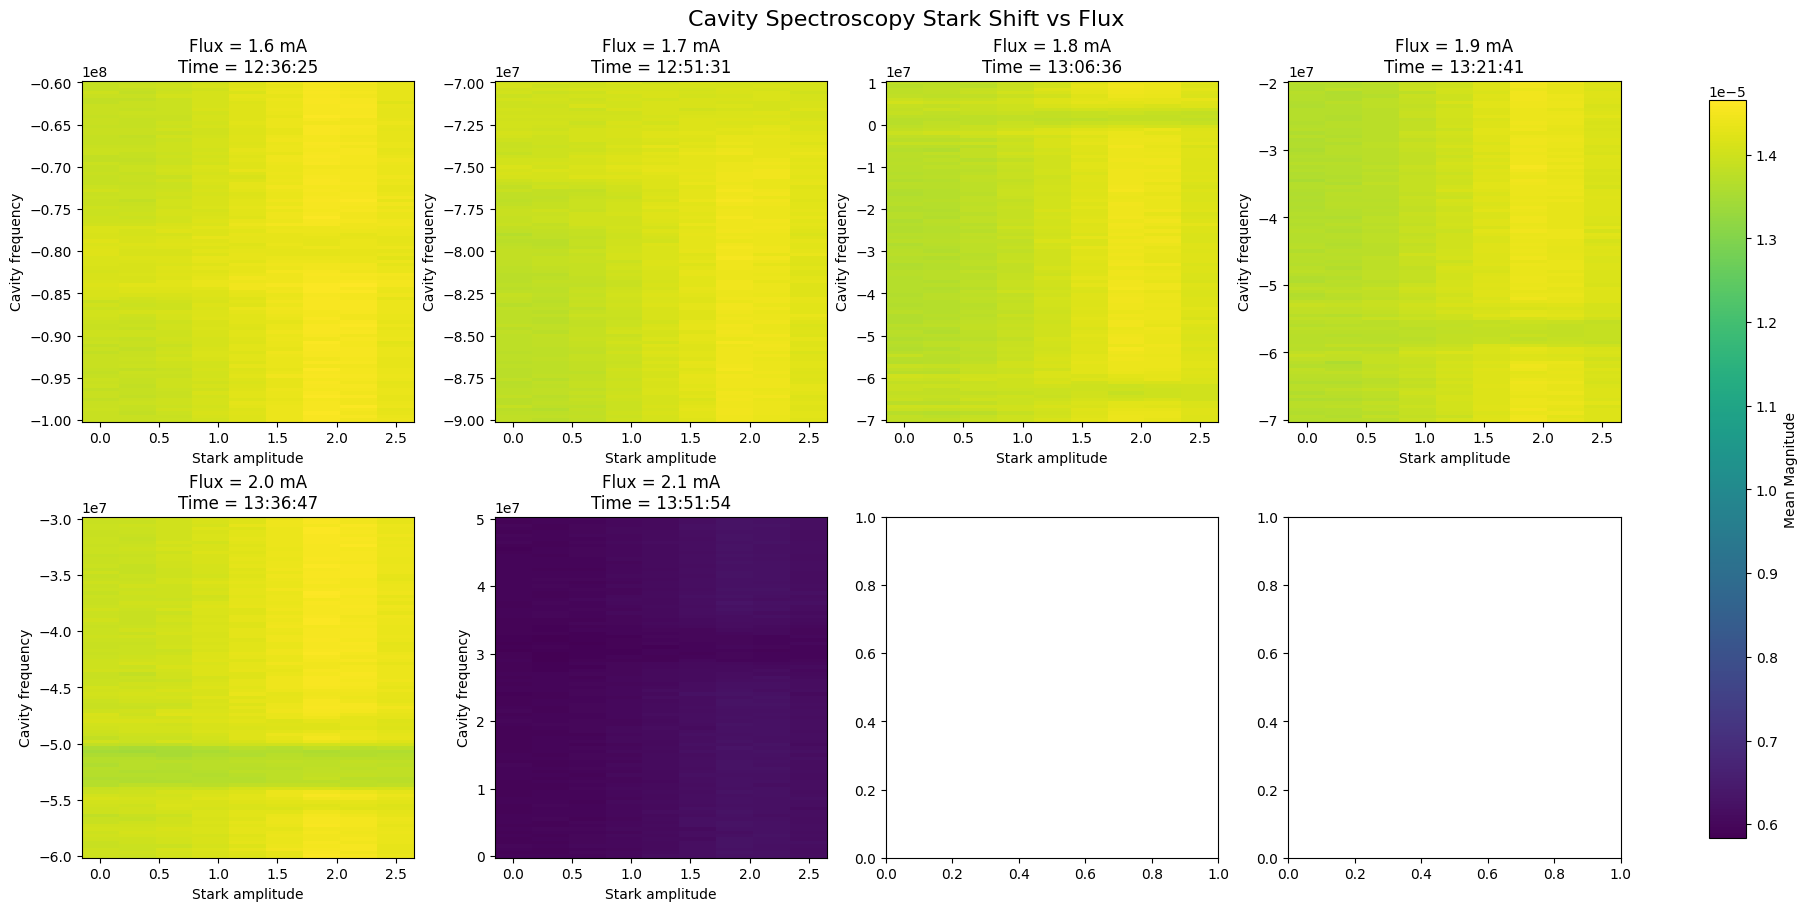

In [13]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

import os
import re
from datetime import time


def collect_hdf5_files(
    folder,
    name_contains,
    start_time,
    end_time,
):
    """
    Collect HDF5 files whose names:

        1. start with HH-MM-SS
        2. contain `name_contains`
        3. fall between start_time and end_time

    Example:
        start_time = "18:20"
        end_time   = "21:59"
    """

    # ------------------------------------------------------
    # Convert "HH:MM" or "HH:MM:SS" -> datetime.time
    # ------------------------------------------------------

    def parse_time_string(s):
        parts = [int(x) for x in s.split(":")]

        if len(parts) == 2:
            return time(parts[0], parts[1], 0)

        elif len(parts) == 3:
            return time(parts[0], parts[1], parts[2])

        else:
            raise ValueError(
                "Time must be 'HH:MM' or 'HH:MM:SS'"
            )

    t_start = parse_time_string(start_time)
    t_end = parse_time_string(end_time)

    # ------------------------------------------------------
    # Search files
    # ------------------------------------------------------

    matched_files = []

    for filename in os.listdir(folder):

        # only HDF5
        if not filename.lower().endswith((".hdf5", ".h5")):
            continue

        # required name / experiment string
        if name_contains not in filename:
            continue

        # extract HH-MM-SS from beginning of filename
        match = re.match(
            r"^(\d{2})-(\d{2})-(\d{2})",
            filename
        )

        if match is None:
            continue

        hh, mm, ss = map(int, match.groups())
        file_time = time(hh, mm, ss)

        # --------------------------------------------------
        # Time selection
        # --------------------------------------------------

        if t_start <= file_time <= t_end:
            matched_files.append(
                (
                    file_time,
                    filename
                )
            )

    # chronological order
    matched_files.sort(key=lambda x: x[0])

    # return filenames only
    return [filename for _, filename in matched_files]


# ==========================================================
# USER SETTINGS
# ==========================================================

folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13"

name_contains = "Cavity_Spec_stark_shift_2D_Flux"

start_time = "12:36"
end_time   = "13:52"


# ==========================================================
# COLLECT FILES
# ==========================================================

filenames = collect_hdf5_files(
    folder=folder,
    name_contains=name_contains,
    start_time=start_time,
    end_time=end_time,
)


# ==========================================================
# SHOW RESULT
# ==========================================================

print(f"Found {len(filenames)} files:\n")

for filename in filenames:
    print(filename)

# Flux corresponding to each file
flux_values = np.linspace(start=1.6e-3, stop=2.5e-3, num=10)

# ==========================================================
# LOAD DATA
# ==========================================================

Z_all = []
freq_all = []
stark_all = []

for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    print(
        f"Loading {filename}  "
        f"Flux = {flux * 1e3:.1f} mA"
    )

    with h5py.File(path, "r") as f:

        magnitude = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    print("    Magnitude shape:", magnitude.shape)
    print("    cavity_frequency shape:", cavity_frequency.shape)
    print("    stark_ampx shape:", stark_ampx.shape)

    # ------------------------------------------------------
    # Average over the 60000-sample waveform axis
    #
    # (60000, 101, 9) -> (101, 9)
    # ------------------------------------------------------

    Z = np.mean(magnitude, axis=0)

    Z_all.append(Z)
    freq_all.append(cavity_frequency)
    stark_all.append(stark_ampx)


Z_all = np.asarray(Z_all)

print()
print("Combined shape:", Z_all.shape)
print("Expected: (8, 101, 9)")


# ==========================================================
# GLOBAL COLOR SCALE
# ==========================================================
# Using the same color limits for every subplot makes the
# eight measurements directly comparable.
# ==========================================================

vmin = np.nanmin(Z_all)
vmax = np.nanmax(Z_all)

print("Color limits:", vmin, vmax)


# ==========================================================
# PLOT 2 x 4 SUBPLOTS
# ==========================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
    constrained_layout=True,
)

axes = axes.ravel()

pcm = None

for i, (ax, filename, flux) in enumerate(
    zip(axes, filenames, flux_values)
):

    Z = Z_all[i]
    cavity_frequency = freq_all[i]
    stark_ampx = stark_all[i]

    pcm = ax.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

    # Convert filename time:
    # 18-20-44 -> 18:20:44
    time_string = filename[:8].replace("-", ":")

    ax.set_title(
        f"Flux = {flux * 1e3:.1f} mA\n"
        f"Time = {time_string}"
    )

    ax.set_xlabel("Stark amplitude")
    ax.set_ylabel("Cavity frequency")


# ==========================================================
# ONE COLORBAR FOR ALL SUBPLOTS
# ==========================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    label="Mean Magnitude",
    shrink=0.95,
)

fig.suptitle(
    "Cavity Spectroscopy Stark Shift vs Flux",
    fontsize=16,
)

plt.show()

Loading 12-36-25_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.6 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 12-51-31_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.7 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-06-36_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.8 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-21-41_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.9 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-36-47_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 2.0 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-51-54_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 2.1 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shap

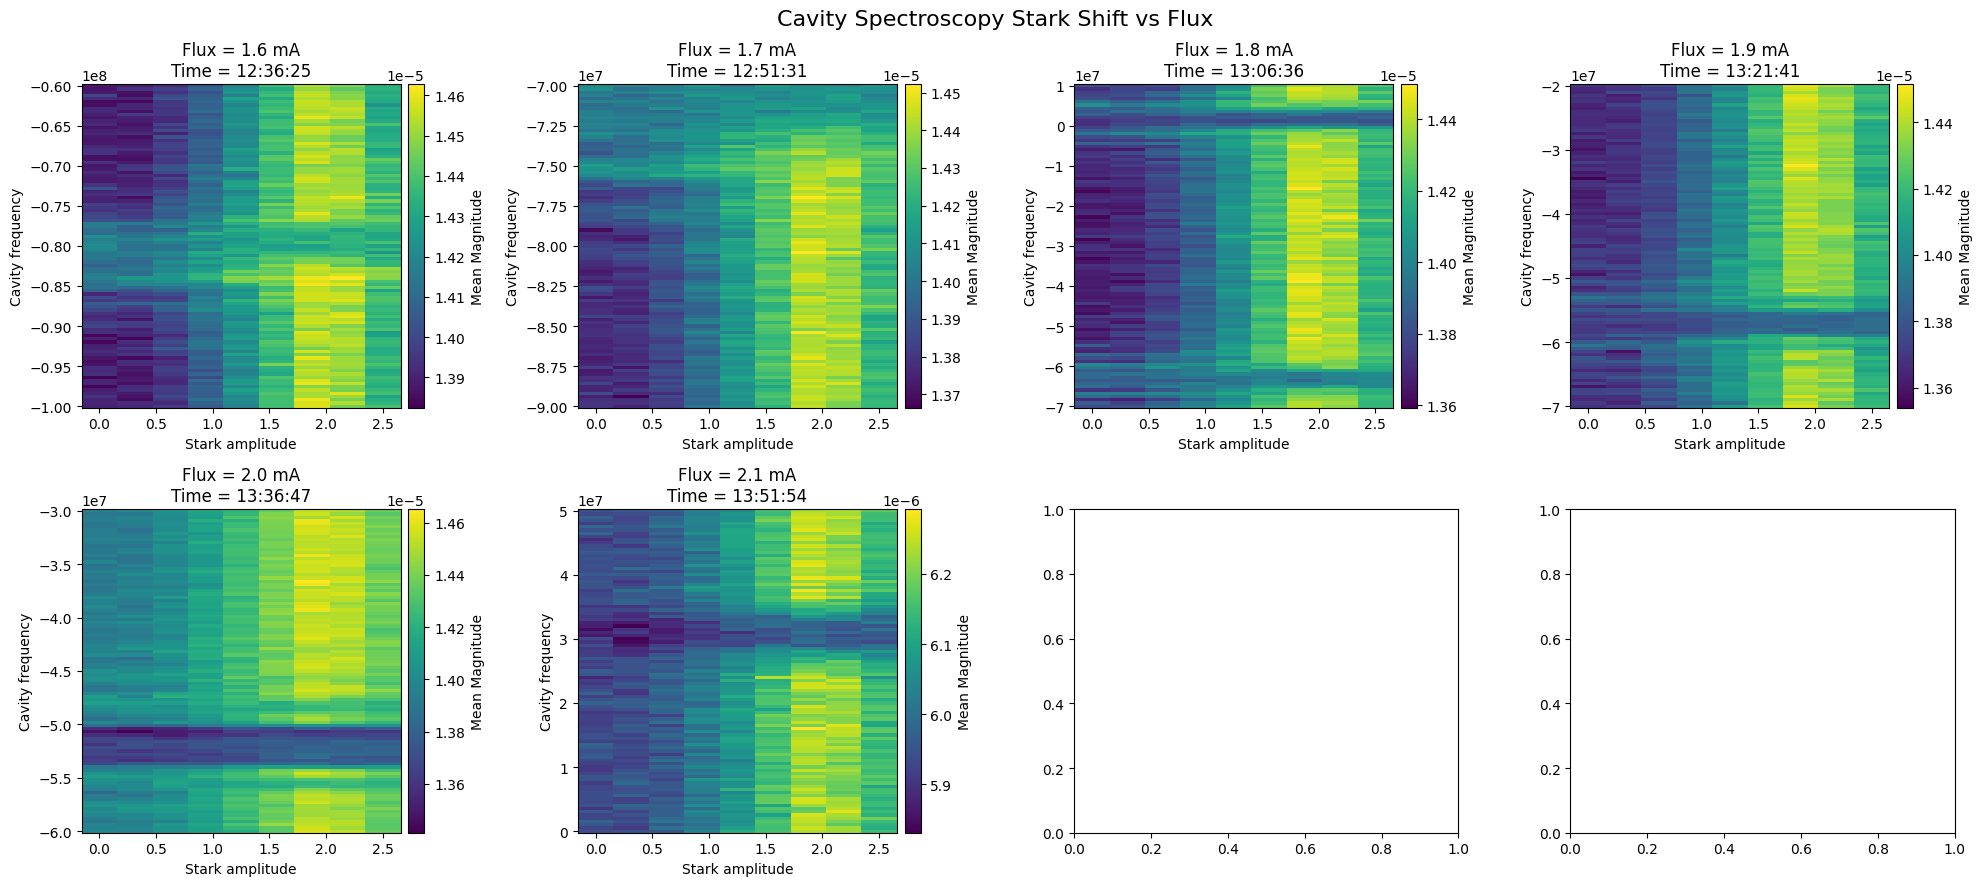

In [14]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

# folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-12"

# filenames = [
#     "18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "19-23-10_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "19-54-23_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "20-25-36_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "20-56-48_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "21-28-01_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "21-59-14_Cavity_Spec_stark_shift_2D_Flux.hdf5",
# ]

# flux_values = np.linspace(
#     start=0.8e-3,
#     stop=1.5e-3,
#     num=8,
# )

# ==========================================================
# LOAD DATA
# ==========================================================

Z_all = []
freq_all = []
stark_all = []

for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    print(
        f"Loading {filename}  "
        f"Flux = {flux * 1e3:.1f} mA"
    )

    with h5py.File(path, "r") as f:
        magnitude = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    print("    Magnitude shape:", magnitude.shape)
    print("    cavity_frequency shape:", cavity_frequency.shape)
    print("    stark_ampx shape:", stark_ampx.shape)

    # (60000, 101, 9) -> (101, 9)
    Z = np.mean(magnitude, axis=0)

    Z_all.append(Z)
    freq_all.append(cavity_frequency)
    stark_all.append(stark_ampx)

Z_all = np.asarray(Z_all)

print()
print("Combined shape:", Z_all.shape)


# ==========================================================
# PLOT 2 x 4 SUBPLOTS
# EACH SUBPLOT HAS ITS OWN COLOR SCALE
# ==========================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20, 9),
)

axes = axes.ravel()

for i, (ax, filename, flux) in enumerate(
    zip(axes, filenames, flux_values)
):

    Z = Z_all[i]
    cavity_frequency = freq_all[i]
    stark_ampx = stark_all[i]

    # ------------------------------------------------------
    # Individual color scale automatically determined
    # from this dataset only
    # ------------------------------------------------------

    pcm = ax.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
    )

    # individual colorbar
    cbar = fig.colorbar(
        pcm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label("Mean Magnitude")

    # filename time: 18-20-44 -> 18:20:44
    time_string = filename[:8].replace("-", ":")

    ax.set_title(
        f"Flux = {flux * 1e3:.1f} mA\n"
        f"Time = {time_string}"
    )

    ax.set_xlabel("Stark amplitude")
    ax.set_ylabel("Cavity frequency")


fig.suptitle(
    "Cavity Spectroscopy Stark Shift vs Flux",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [4]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import time

# ==========================================================
# SETTINGS
# ==========================================================

folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-12"

start_time = time(18, 20)
end_time   = time(21, 59, 59)


# ==========================================================
# FIND ALL HDF5 FILES IN TIME RANGE
# ==========================================================

files = []

for filename in os.listdir(folder):

    if not filename.lower().endswith((".hdf5", ".h5")):
        continue

    # Expect filename beginning with HH-MM-SS
    match = re.match(r"(\d{2})-(\d{2})-(\d{2})", filename)

    if match is None:
        continue

    hh, mm, ss = map(int, match.groups())
    file_time = time(hh, mm, ss)

    if start_time <= file_time <= end_time:
        files.append(
            (
                file_time,
                os.path.join(folder, filename)
            )
        )

# sort chronologically
files.sort(key=lambda x: x[0])

print(f"Found {len(files)} files:\n")

for t, path in files:
    print(t, os.path.basename(path))


# ==========================================================
# SHOW HDF5 KEYS / SHAPES FOR EVERY FILE
# ==========================================================

for t, path in files:

    print("\n")
    print("=" * 100)
    print(t, os.path.basename(path))
    print("=" * 100)

    try:
        with h5py.File(path, "r") as f:

            def show_item(name, obj):
                if isinstance(obj, h5py.Dataset):
                    print(
                        f"{name:30s} "
                        f"shape={str(obj.shape):20s} "
                        f"dtype={obj.dtype}"
                    )

            f.visititems(show_item)

    except Exception as e:
        print("ERROR:", e)
        
all_mag = []
all_freq = []
all_stark = []
all_filenames = []

for t, path in files:

    with h5py.File(path, "r") as f:

        # only use files containing these datasets
        if not all(k in f for k in ["Magnitude", "cavity_frequency", "stark_ampx"]):
            continue

        mag = f["Magnitude"][()]
        freq = f["cavity_frequency"][()]
        stark = f["stark_ampx"][()]

        print(
            os.path.basename(path),
            "Magnitude:", mag.shape,
            "freq:", freq.shape,
            "stark:", stark.shape,
        )

        all_mag.append(mag)
        all_freq.append(freq)
        all_stark.append(stark)
        all_filenames.append(os.path.basename(path))

Found 8 files:

18:20:44 18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5
18:51:57 18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5
19:23:10 19-23-10_Cavity_Spec_stark_shift_2D_Flux.hdf5
19:54:23 19-54-23_Cavity_Spec_stark_shift_2D_Flux.hdf5
20:25:36 20-25-36_Cavity_Spec_stark_shift_2D_Flux.hdf5
20:56:48 20-56-48_Cavity_Spec_stark_shift_2D_Flux.hdf5
21:28:01 21-28-01_Cavity_Spec_stark_shift_2D_Flux.hdf5
21:59:14 21-59-14_Cavity_Spec_stark_shift_2D_Flux.hdf5


18:20:44 18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5
I                              shape=(60000, 101, 9)      dtype=float64
Magnitude                      shape=(60000, 101, 9)      dtype=float64
Q                              shape=(60000, 101, 9)      dtype=float64
cavity_frequency               shape=(101,)               dtype=int32
stark_ampx                     shape=(9,)                 dtype=float64


18:51:57 18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5
I                              shape=(60000, 101, 9)      dtype=float64


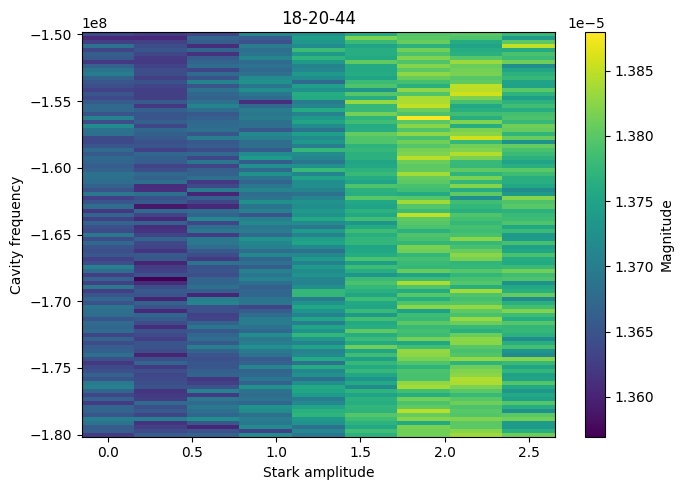

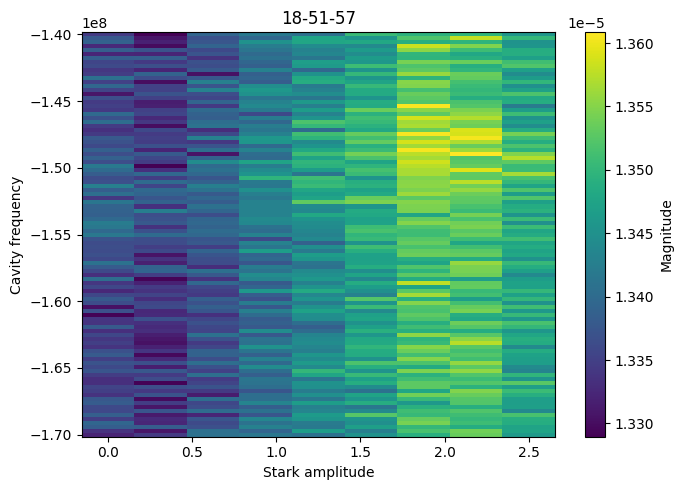

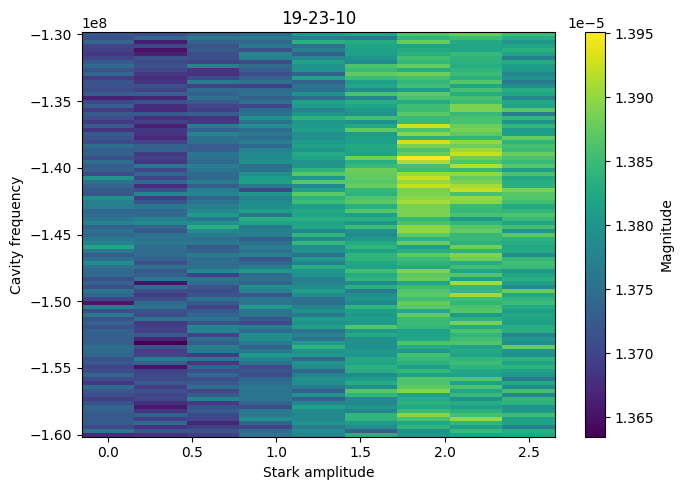

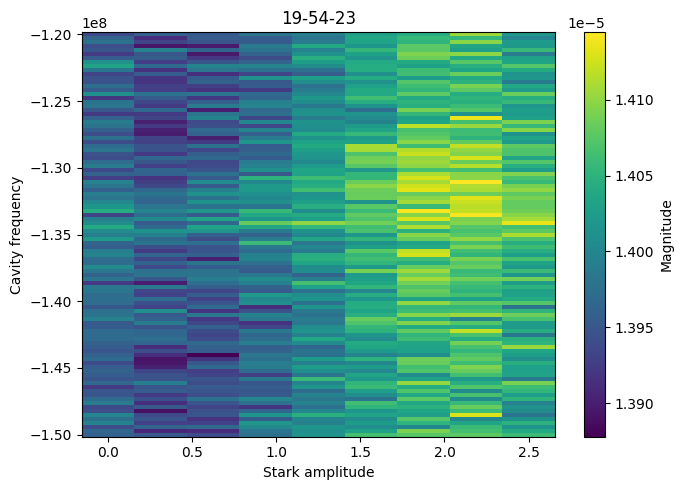

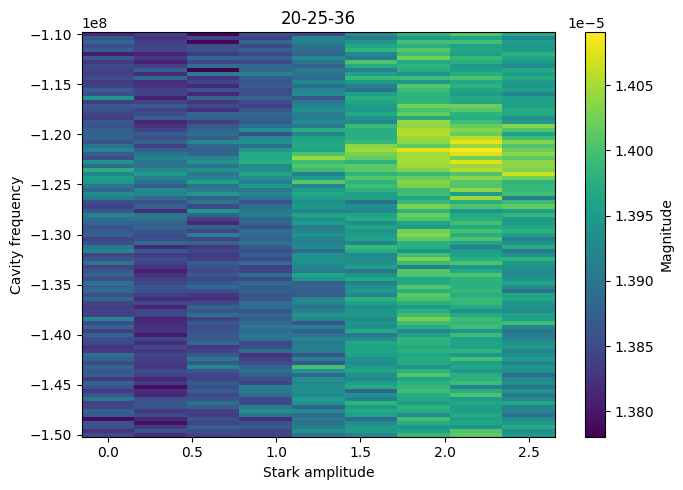

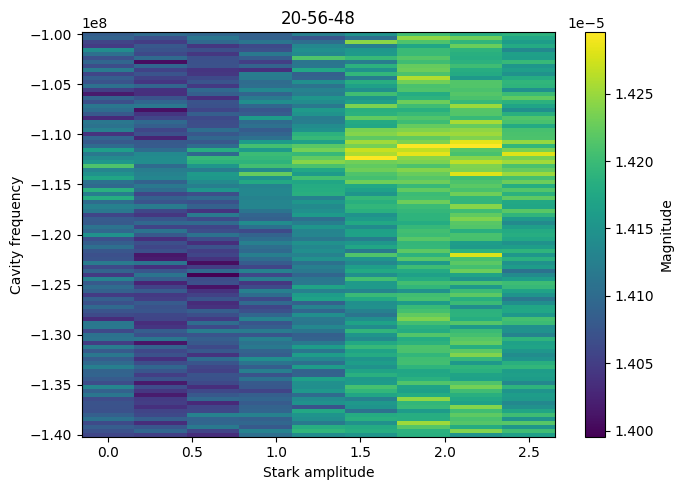

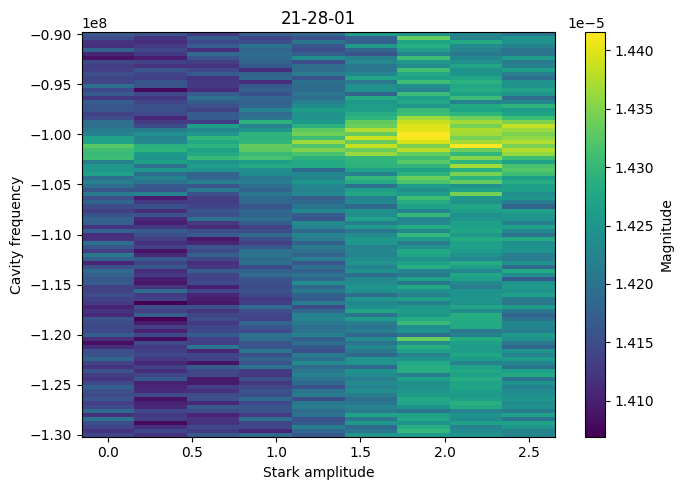

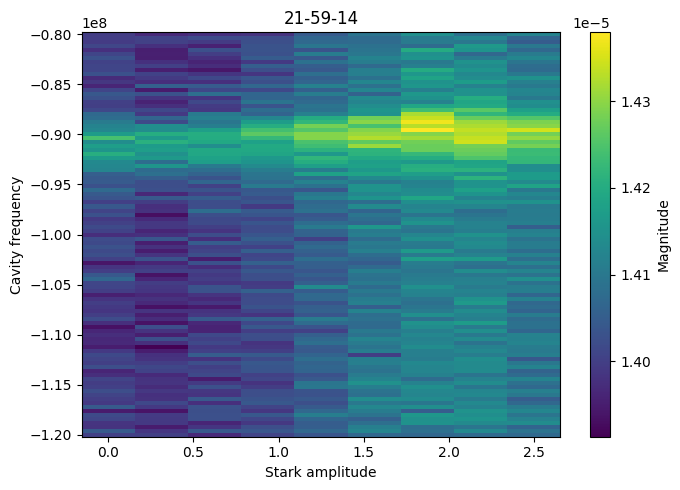

In [6]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

for t, path in files:

    with h5py.File(path, "r") as f:
        mag = f["Magnitude"][()]
        freq = f["cavity_frequency"][()]
        stark = f["stark_ampx"][()]

    # (60000, 101, 9) -> (101, 9)
    Z = np.mean(mag, axis=0)

    plt.figure(figsize=(7, 5))

    plt.pcolormesh(
        stark,
        freq,
        Z,
        shading="auto",
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Stark amplitude")
    plt.ylabel("Cavity frequency")
    plt.title(os.path.basename(path)[:8])

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-12"

filenames = [
    "18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "19-23-10_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "19-54-23_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "20-25-36_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "20-56-48_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "21-28-01_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "21-59-14_Cavity_Spec_stark_shift_2D_Flux.hdf5",
]

flux_values = np.linspace(
    start=0.8e-3,
    stop=1.5e-3,
    num=8
)

print("File -> Flux")
for filename, flux in zip(filenames, flux_values):
    print(f"{filename[:8]} -> {flux*1e3:.3f} mA")


# ==========================================================
# Load and reduce each file
#
# Original:
#   Magnitude.shape = (60000, 101, 9)
#
# After averaging trace axis:
#   (101, 9)
#
# Combined:
#   (8, 101, 9)
#   = (flux, cavity_frequency, stark_ampx)
# ==========================================================

Z_all = []

for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    with h5py.File(path, "r") as f:
        mag = f["Magnitude"][()]

        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    # 60000 x 101 x 9 -> 101 x 9
    Z = np.mean(mag, axis=0)

    Z_all.append(Z)

Z_all = np.array(Z_all)

print("\nCombined shape:", Z_all.shape)
# should be:
# (8, 101, 9)

File -> Flux
18-20-44 -> 0.800 mA
18-51-57 -> 0.900 mA
19-23-10 -> 1.000 mA
19-54-23 -> 1.100 mA
20-25-36 -> 1.200 mA
20-56-48 -> 1.300 mA
21-28-01 -> 1.400 mA
21-59-14 -> 1.500 mA

Combined shape: (8, 101, 9)


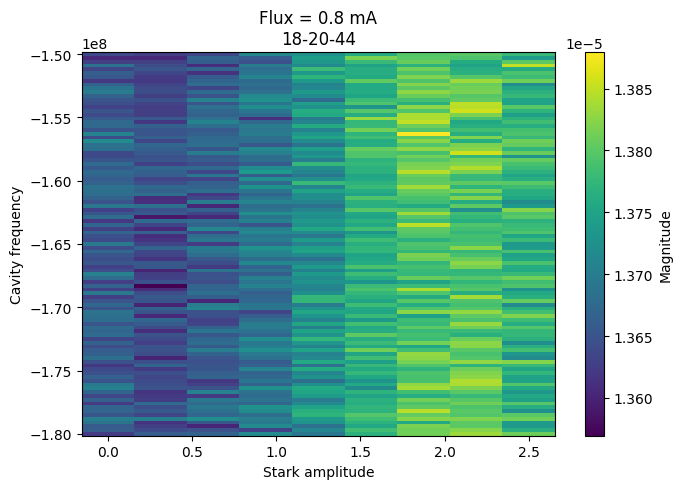

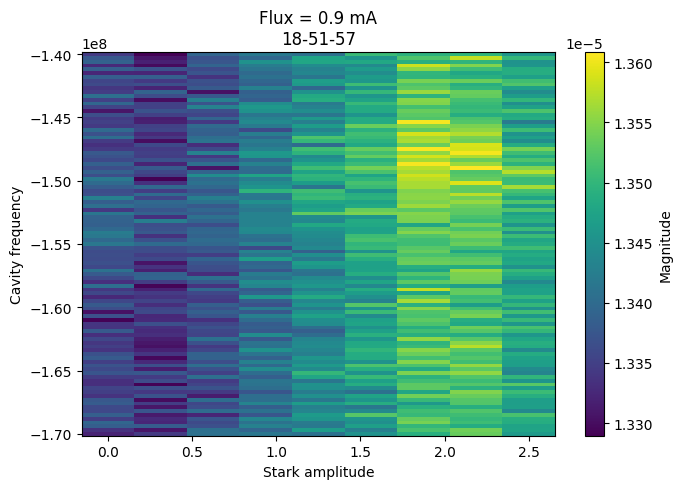

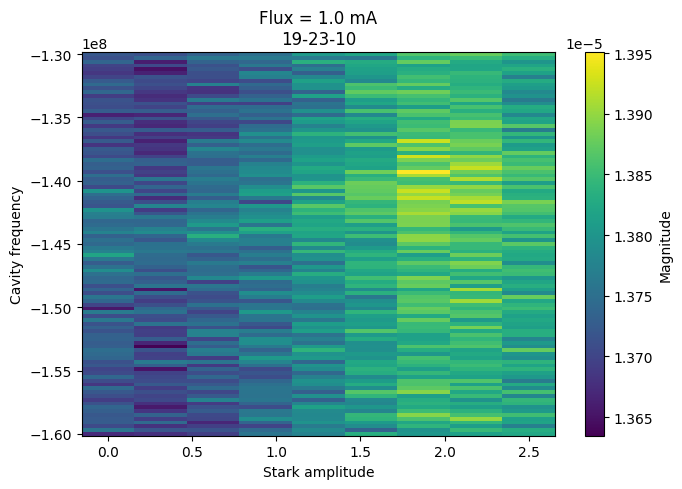

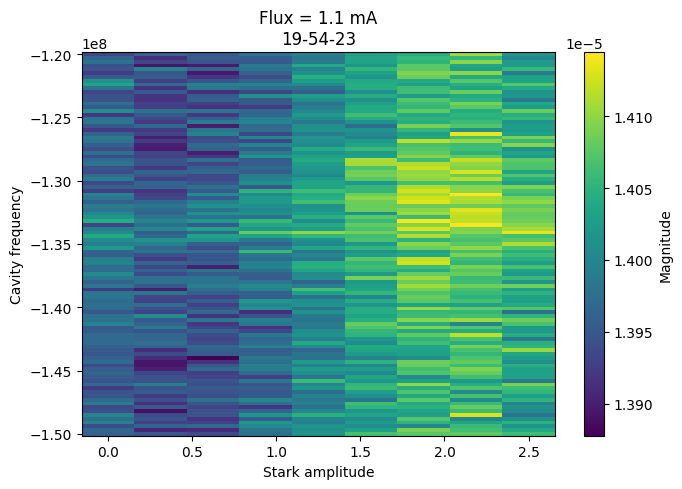

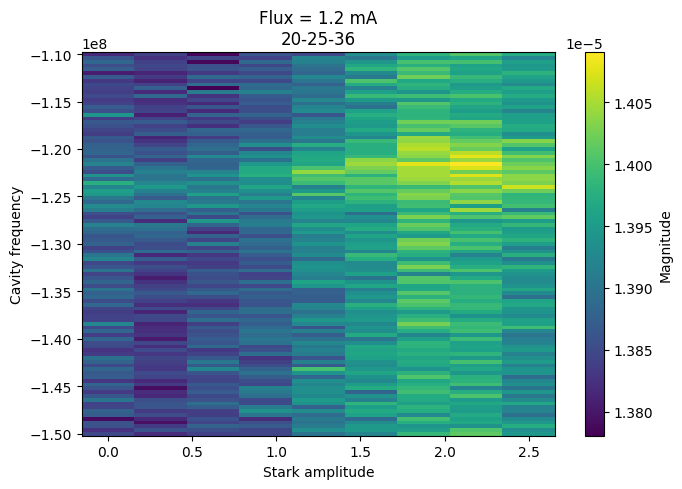

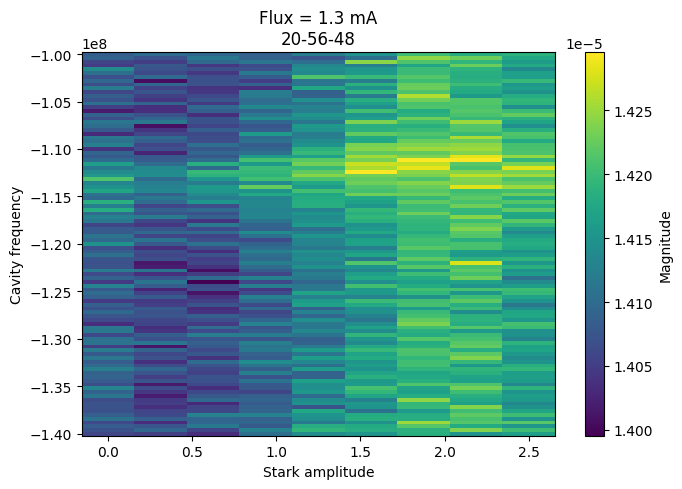

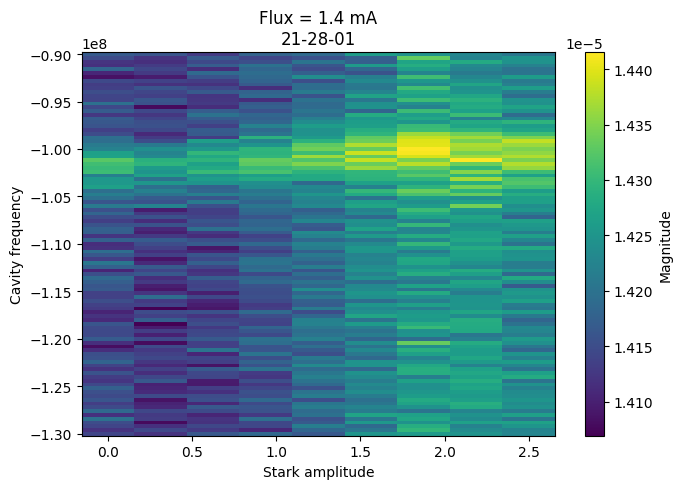

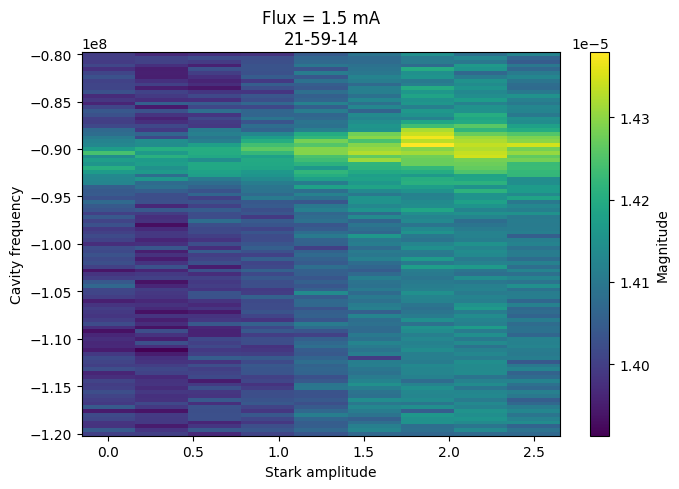

In [8]:
for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    with h5py.File(path, "r") as f:
        mag = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    Z = np.mean(mag, axis=0)   # (101, 9)

    plt.figure(figsize=(7, 5))

    plt.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Stark amplitude")
    plt.ylabel("Cavity frequency")

    plt.title(
        f"Flux = {flux*1e3:.1f} mA\n"
        f"{filename[:8]}"
    )

    plt.tight_layout()
    plt.show()